Dataset Shape: (35717, 4)

Column Names:
['SystemCodeNumber', 'Capacity', 'Occupancy', 'LastUpdated']

Data Types:
SystemCodeNumber    object
Capacity             int64
Occupancy            int64
LastUpdated         object
dtype: object

First 5 Records:


,SystemCodeNumber,Capacity,Occupancy,LastUpdated
0,BHMBCCMKT01,577,61,2016-10-04 07:59:42
1,BHMBCCMKT01,577,64,2016-10-04 08:25:42
2,BHMBCCMKT01,577,80,2016-10-04 08:59:42
3,BHMBCCMKT01,577,107,2016-10-04 09:32:46
4,BHMBCCMKT01,577,150,2016-10-04 09:59:48



Missing Values:
SystemCodeNumber    0
Capacity            0
Occupancy           0
LastUpdated         0
dtype: int64

Duplicate Rows: 216

Statistical Summary:


,Capacity,Occupancy
count,35717.000000,35717.000000
mean,1397.550130,642.228911
std,1179.326833,656.955535
min,220.000000,-8.000000
25%,500.000000,210.000000
50%,849.000000,446.000000
75%,2009.000000,798.000000
max,4675.000000,4327.000000



Number of Parking Locations: 30

Parking Locations:
['BHMBCCMKT01' 'BHMBCCPST01' 'BHMBCCSNH01' 'BHMBCCTHL01' 'BHMBRCBRG01'
 'BHMBRCBRG02' 'BHMBRCBRG03' 'BHMBRTARC01' 'BHMEURBRD01' 'BHMEURBRD02'
 'BHMMBMMBX01' 'BHMNCPHST01' 'BHMNCPLDH01' 'BHMNCPNHS01' 'BHMNCPNST01'
 'BHMNCPPLS01' 'BHMNCPRAN01' 'Broad Street' 'Bull Ring' 'NIA Car Parks'
 'NIA North' 'NIA South' 'Others-CCCPS105a' 'Others-CCCPS119a'
 'Others-CCCPS133' 'Others-CCCPS135a' 'Others-CCCPS202' 'Others-CCCPS8'
 'Others-CCCPS98' 'Shopping']

Negative Occupancy Records: 12


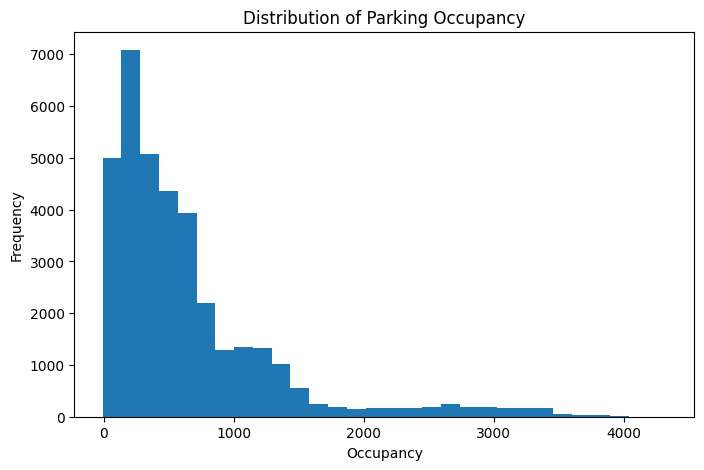

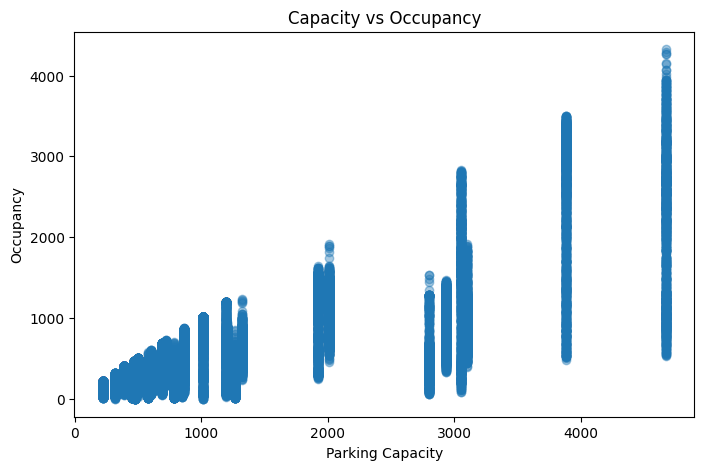

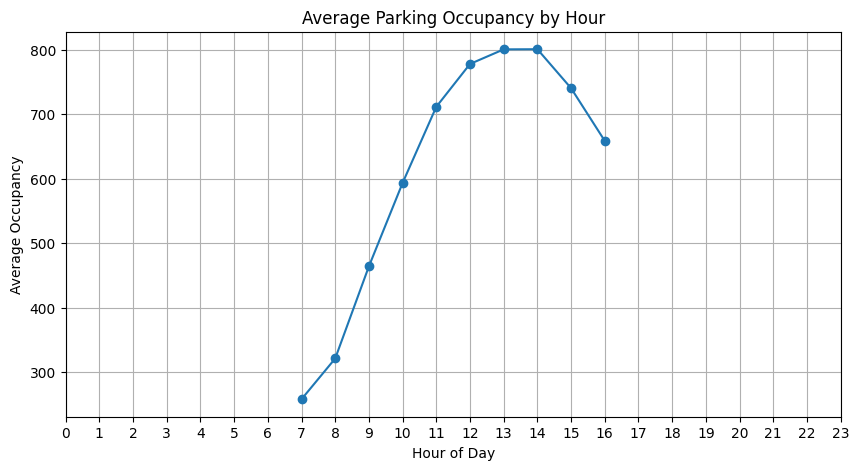

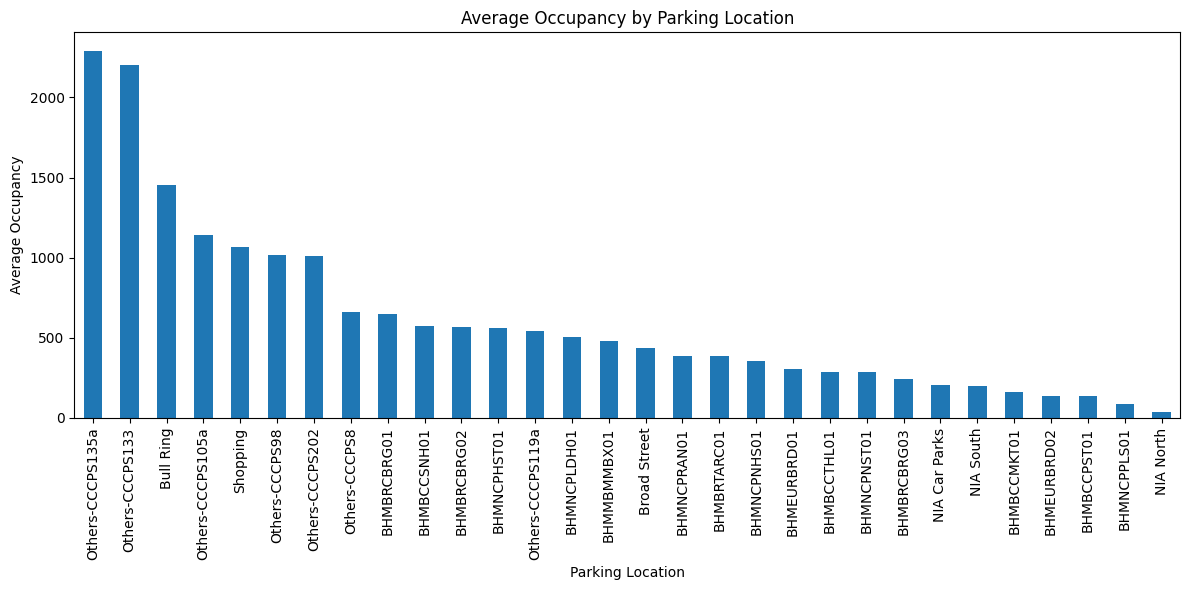


Correlation Matrix:


,Capacity,Occupancy,Hour
Capacity,1.000000,0.775825,0.002229
Occupancy,0.775825,1.000000,0.199852
Hour,0.002229,0.199852,1.000000


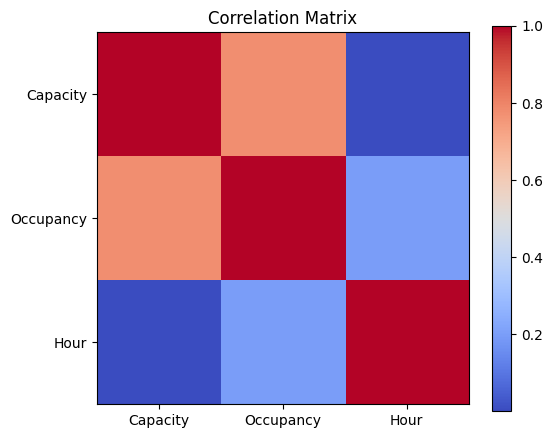

In [ ]:
# ============================================
# EDA - Birmingham Parking Dataset
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("parking_birmingham.csv")

# -----------------------------
# 1. Basic Dataset Information
# -----------------------------

print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

# -----------------------------
# 2. First 5 Records
# -----------------------------

print("\nFirst 5 Records:")
display(df.head())

# -----------------------------
# 3. Missing Values
# -----------------------------

print("\nMissing Values:")
print(df.isnull().sum())

# -----------------------------
# 4. Duplicate Records
# -----------------------------

print("\nDuplicate Rows:", df.duplicated().sum())

# -----------------------------
# 5. Statistical Summary
# -----------------------------

print("\nStatistical Summary:")
display(df.describe())

# -----------------------------
# 6. Unique Parking Locations
# -----------------------------

print("\nNumber of Parking Locations:",
      df["SystemCodeNumber"].nunique())

print("\nParking Locations:")
print(df["SystemCodeNumber"].unique())

# -----------------------------
# 7. Check Negative Occupancy
# -----------------------------

negative_count = (df["Occupancy"] < 0).sum()

print("\nNegative Occupancy Records:", negative_count)

# -----------------------------
# 8. Convert Date-Time
# -----------------------------

df["LastUpdated"] = pd.to_datetime(df["LastUpdated"])

# Extract hour
df["Hour"] = df["LastUpdated"].dt.hour

# -----------------------------
# 9. Occupancy Distribution
# -----------------------------

plt.figure(figsize=(8, 5))

plt.hist(df["Occupancy"], bins=30)

plt.xlabel("Occupancy")
plt.ylabel("Frequency")
plt.title("Distribution of Parking Occupancy")

plt.show()

# -----------------------------
# 10. Capacity vs Occupancy
# -----------------------------

plt.figure(figsize=(8, 5))

plt.scatter(df["Capacity"], df["Occupancy"], alpha=0.4)

plt.xlabel("Parking Capacity")
plt.ylabel("Occupancy")
plt.title("Capacity vs Occupancy")

plt.show()

# -----------------------------
# 11. Average Occupancy by Hour
# -----------------------------

hourly_occupancy = df.groupby("Hour")["Occupancy"].mean()

plt.figure(figsize=(10, 5))

plt.plot(hourly_occupancy.index,
         hourly_occupancy.values,
         marker="o")

plt.xlabel("Hour of Day")
plt.ylabel("Average Occupancy")
plt.title("Average Parking Occupancy by Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

# -----------------------------
# 12. Average Occupancy
#     by Parking Location
# -----------------------------

location_occupancy = (
    df.groupby("SystemCodeNumber")["Occupancy"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 6))

location_occupancy.plot(kind="bar")

plt.xlabel("Parking Location")
plt.ylabel("Average Occupancy")
plt.title("Average Occupancy by Parking Location")

plt.xticks(rotation=90)
plt.tight_layout()

plt.show()

# -----------------------------
# 13. Correlation Matrix
# -----------------------------

correlation = df[
    ["Capacity", "Occupancy", "Hour"]
].corr()

print("\nCorrelation Matrix:")
display(correlation)

plt.figure(figsize=(6, 5))

plt.imshow(correlation, cmap="coolwarm")

plt.colorbar()

plt.xticks(range(len(correlation.columns)),
           correlation.columns)

plt.yticks(range(len(correlation.columns)),
           correlation.columns)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
!pip -q install ydata-profiling

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 682.5/682.5 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00


In [ ]:
from ydata_profiling import ProfileReport
from google.colab import files
import pandas as pd

# Load dataset
df = pd.read_csv("parking_birmingham.csv")

# Generate EDA report
profile = ProfileReport(
    df,
    title="Birmingham Parking Dataset - EDA Report",
    explorative=True
)

# Save report
profile.to_file("Parking_EDA_Report.html")

# Automatically download
files.download("Parking_EDA_Report.html")

/tmp/ipykernel_2803/3466073814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please install fg-data-profiling via `pip install fg-data-profiling` and use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 4/4 [00:00<00:00,  6.79it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>